<a href="https://colab.research.google.com/github/chirontorudrapaul/AI-_ML/blob/main/ICDAI_CP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import QuantileTransformer

# Load original dataset
df = pd.read_csv("/content/sample_data/ICDAI2026 - mfs_Validate_Final.csv")

# Drop missing values
df = df.dropna()

# Select numeric columns only for modeling
num_cols = df.select_dtypes(include=np.number).columns

# Step 1: Transform to uniform distribution
qt = QuantileTransformer(output_distribution='normal')
data_normal = qt.fit_transform(df[num_cols])

# Step 2: Estimate correlation
corr = np.corrcoef(data_normal, rowvar=False)

# Step 3: Generate synthetic data
n_samples = 2100
mean = np.zeros(len(num_cols))

synthetic_normal = np.random.multivariate_normal(mean, corr, n_samples)

# Step 4: Transform back to original distribution
synthetic_data = qt.inverse_transform(synthetic_normal)

synthetic_df = pd.DataFrame(synthetic_data, columns=num_cols)

# Step 5: Add categorical columns (sampling)
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    synthetic_df[col] = np.random.choice(df[col], size=n_samples, replace=True)

# Save dataset
synthetic_df.to_csv("synthetic_dataset_2100.csv", index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


In [ ]:
for col in num_cols:
    stat, p = stats.ks_2samp(df[col], synthetic_df[col])
    print(col, "p-value:", p)

PE1 p-value: 0.591691248019568
PE2 p-value: 0.9988580592320063
PE3 p-value: 0.2804576889128164
PE4 p-value: 1.0
EE1 p-value: 0.973939669052111
EE2 p-value: 0.9942526115451393
EE3 p-value: 0.1489183993143387
EE4 p-value: 0.3442034019836093
PR1 p-value: 0.13278384208939886
PR2 p-value: 0.9782919617235392
PR3 p-value: 0.8403810891131316
PR4 p-value: 0.2645551244721204
FC1 p-value: 0.5046610391860658
FC2 p-value: 0.9978744601377708
FC3 p-value: 0.9999858410422646
FC4 p-value: 0.8211771651086941
PE p-value: 0.20192308289645733
EE p-value: 0.08433240533194108
PR p-value: 0.017383905623470634
FC p-value: 0.3758035882906684
Churn p-value: 1.0


In [ ]:
orig_corr = df[num_cols].corr()
syn_corr = synthetic_df[num_cols].corr()

diff = (orig_corr - syn_corr).abs().mean().mean()
print("Correlation difference:", diff)

Correlation difference: 0.020874860109334776


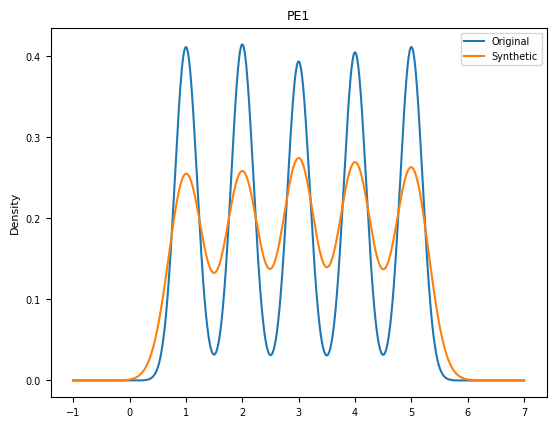

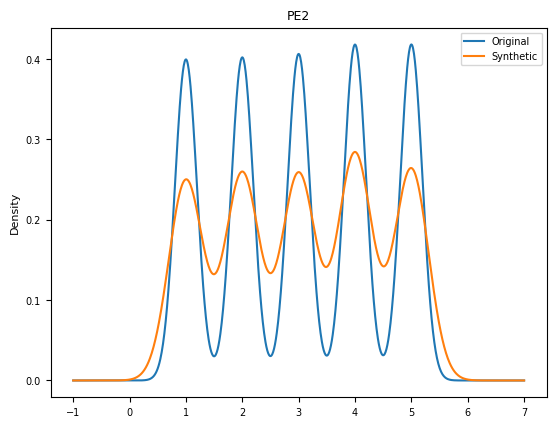

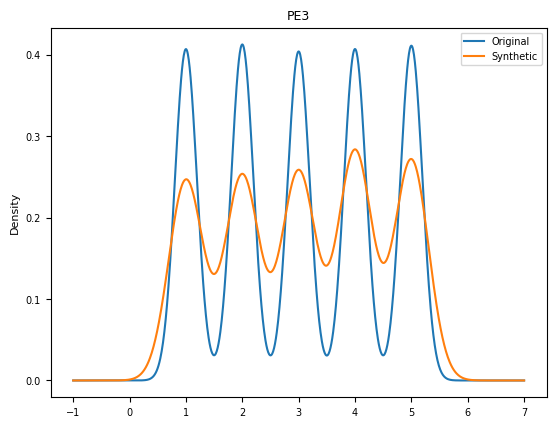

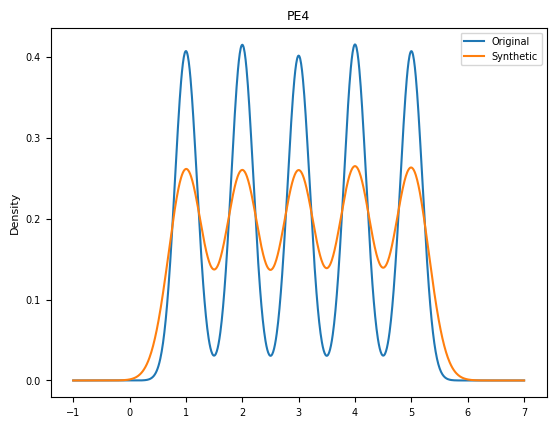

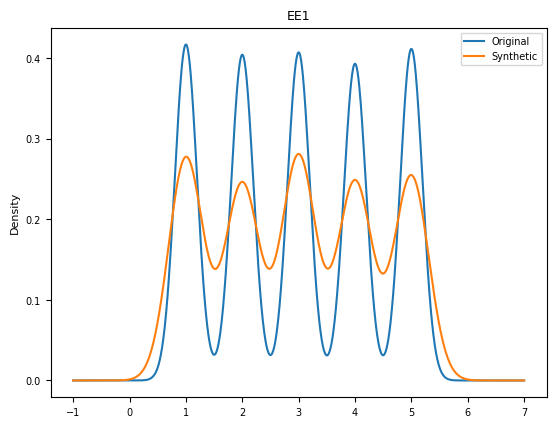

In [ ]:
import matplotlib.pyplot as plt

for col in num_cols[:5]:
    plt.figure()
    df[col].plot(kind='kde', label='Original')
    synthetic_df[col].plot(kind='kde', label='Synthetic')
    plt.legend()
    plt.title(col)
    plt.show()

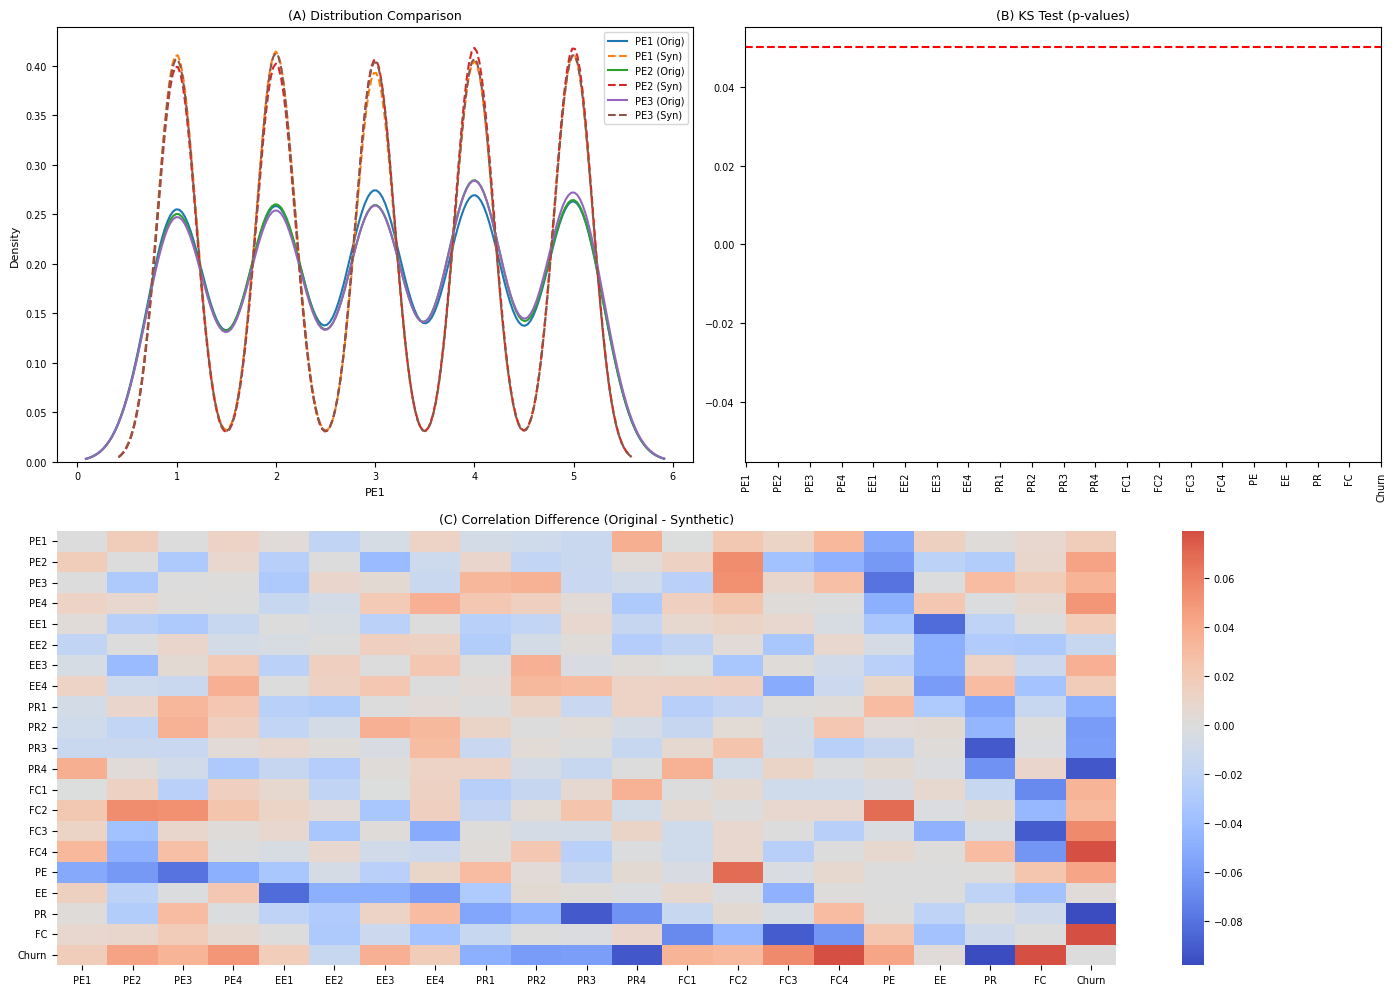

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load datasets
orig = pd.read_csv("/content/synthetic_dataset_2100.csv")
syn = pd.read_csv("/content/sample_data/ICDAI2026 - mfs_Validate_Final.csv")

num_cols = orig.select_dtypes(include=np.number).columns

fig = plt.figure(figsize=(14,10))

# -----------------------
# (A) Distribution Plot
# -----------------------
ax1 = plt.subplot2grid((2,2),(0,0))

for col in num_cols[:3]:  # show 3 key features
    sns.kdeplot(orig[col], ax=ax1, label=f"{col} (Orig)")
    sns.kdeplot(syn[col], ax=ax1, linestyle="--", label=f"{col} (Syn)")

ax1.set_title("(A) Distribution Comparison")
ax1.legend()

# -----------------------
# (B) KS Test
# -----------------------
ax2 = plt.subplot2grid((2,2),(0,1))

p_values = []
for col in num_cols:
    _, p = stats.ks_2samp(orig[col], syn[col])
    p_values.append(p)

ax2.bar(range(len(num_cols)), p_values)
ax2.axhline(0.05, color='red', linestyle='--')
ax2.set_title("(B) KS Test (p-values)")
ax2.set_xticks(range(len(num_cols)))
ax2.set_xticklabels(num_cols, rotation=90)

# -----------------------
# (C) Correlation Heatmap
# -----------------------
ax3 = plt.subplot2grid((2,2),(1,0), colspan=2)

corr_diff = orig[num_cols].corr() - syn[num_cols].corr()

sns.heatmap(corr_diff, cmap="coolwarm", center=0, ax=ax3)
ax3.set_title("(C) Correlation Difference (Original - Synthetic)")

plt.tight_layout()
plt.show()

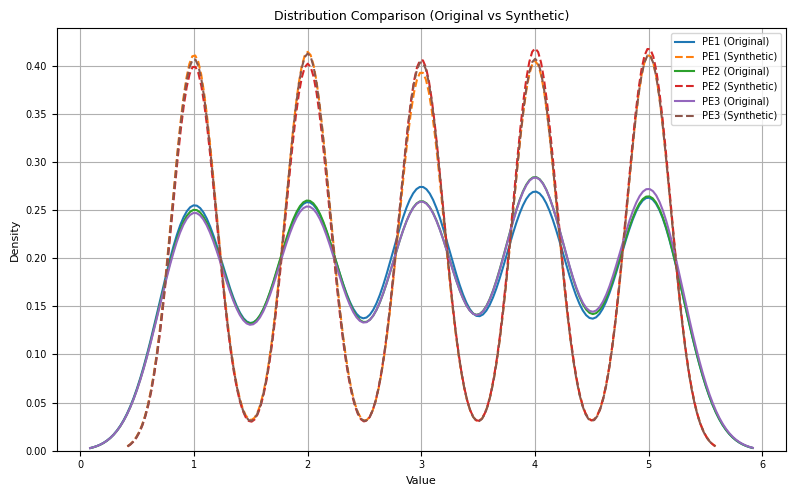

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
orig = pd.read_csv("/content/synthetic_dataset_2100.csv")
syn = pd.read_csv("/content/sample_data/ICDAI2026 - mfs_Validate_Final.csv")

num_cols = orig.select_dtypes(include='number').columns

plt.figure(figsize=(8,5))

# Plot only key features (avoid clutter)
features = ['PE1', 'PE2', 'PE3']

for col in features:
    sns.kdeplot(orig[col], label=f"{col} (Original)")
    sns.kdeplot(syn[col], linestyle="--", label=f"{col} (Synthetic)")

plt.title("Distribution Comparison (Original vs Synthetic)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

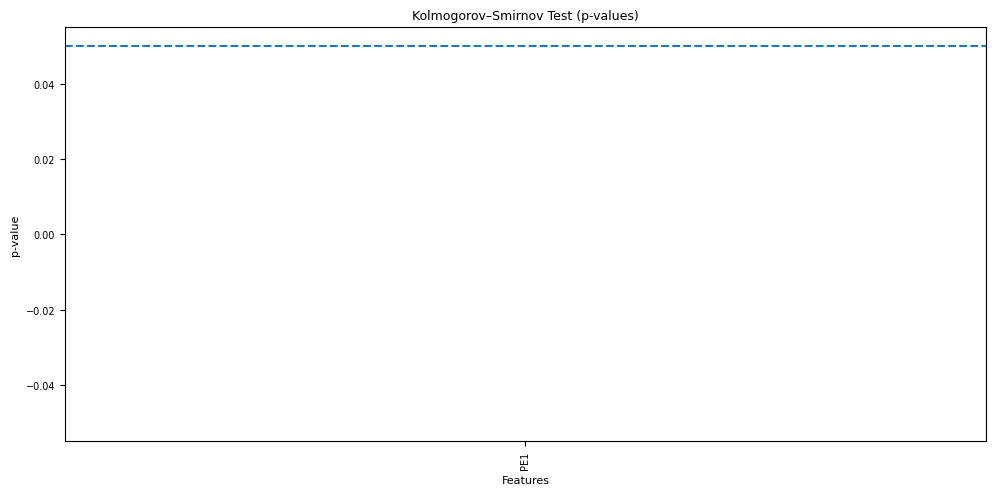

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

p_values = []

for col in num_cols:
    _, p = stats.ks_2samp(orig[col], syn[col])
    p_values.append(p)

plt.figure(figsize=(10,5))

plt.bar(num_cols, p_values)
plt.axhline(y=0.05, linestyle='--')  # significance threshold

plt.title("Kolmogorov–Smirnov Test (p-values)")
plt.xlabel("Features")
plt.ylabel("p-value")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

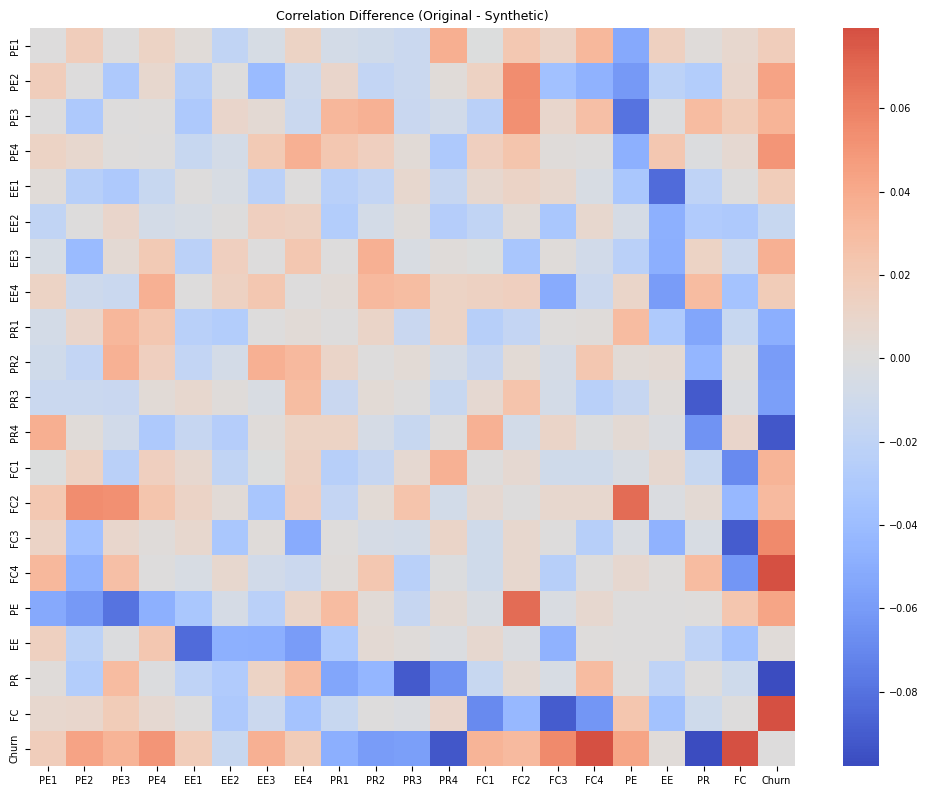

In [ ]:
import seaborn as sns

# Compute correlation matrices
corr_orig = orig[num_cols].corr()
corr_syn = syn[num_cols].corr()

# Difference
corr_diff = corr_orig - corr_syn

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_diff,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Difference (Original - Synthetic)")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Load datasets
orig = pd.read_csv("/content/synthetic_dataset_2100.csv")
syn = pd.read_csv("/content/sample_data/ICDAI2026 - mfs_Validate_Final.csv")

# Drop missing values
orig = orig.dropna()
syn = syn.dropna()

# Select numeric columns
num_cols = orig.select_dtypes(include=np.number).columns

print("Total Features:", len(num_cols))

Total Features: 21


In [ ]:
summary = pd.DataFrame({
    "Feature": num_cols,
    "Orig_Mean": orig[num_cols].mean().values,
    "Syn_Mean": syn[num_cols].mean().values,
    "Orig_Std": orig[num_cols].std().values,
    "Syn_Std": syn[num_cols].std().values
})

summary["Mean_Diff"] = abs(summary["Orig_Mean"] - summary["Syn_Mean"])
summary["Std_Diff"] = abs(summary["Orig_Std"] - summary["Syn_Std"])

print(summary.round(4))

   Feature  Orig_Mean  Syn_Mean  Orig_Std  Syn_Std  Mean_Diff  Std_Diff
0      PE1     3.0199    2.9953    1.4043   1.4210     0.0246    0.0166
1      PE2     3.0401    3.0260    1.4053   1.4144     0.0141    0.0091
2      PE3     3.0605    3.0014    1.4094   1.4157     0.0592    0.0062
3      PE4     3.0067    3.0001    1.4164   1.4134     0.0066    0.0030
4      EE1     2.9665    2.9891    1.4175   1.4220     0.0226    0.0046
5      EE2     3.0244    3.0244    1.4297   1.4137     0.0000    0.0159
6      EE3     2.9054    2.9897    1.4112   1.4160     0.0843    0.0048
7      EE4     2.9758    3.0069    1.4062   1.4114     0.0312    0.0052
8      PR1     2.9209    2.9835    1.4212   1.4140     0.0626    0.0071
9      PR2     2.9659    3.0050    1.4122   1.4135     0.0390    0.0013
10     PR3     2.9728    3.0000    1.4224   1.4091     0.0272    0.0133
11     PR4     2.9515    3.0094    1.4195   1.4183     0.0578    0.0013
12     FC1     2.9513    2.9888    1.4261   1.4125     0.0374   

In [ ]:
from scipy import stats

ks_results = []

for col in num_cols:
    stat, p = stats.ks_2samp(orig[col], syn[col])
    ks_results.append([col, stat, p])

ks_df = pd.DataFrame(ks_results, columns=["Feature", "KS_Stat", "p_value"])

print(ks_df.round(4))


   Feature  KS_Stat  p_value
0      PE1   0.0176   0.5917
1      PE2   0.0086   0.9989
2      PE3   0.0226   0.2805
3      PE4   0.0037   1.0000
4      EE1   0.0110   0.9739
5      EE2   0.0096   0.9943
6      EE3   0.0261   0.1489
7      EE4   0.0214   0.3442
8      PR1   0.0266   0.1328
9      PR2   0.0108   0.9783
10     PR3   0.0141   0.8404
11     PR4   0.0230   0.2646
12     FC1   0.0188   0.5047
13     FC2   0.0089   0.9979
14     FC3   0.0069   1.0000
15     FC4   0.0144   0.8212
16      PE   0.0245   0.2019
17      EE   0.0288   0.0843
18      PR   0.0352   0.0174
19      FC   0.0208   0.3758
20   Churn   0.0035   1.0000


In [ ]:
corr_orig = orig[num_cols].corr()
corr_syn = syn[num_cols].corr()

# Difference matrix
corr_diff = corr_orig - corr_syn

# Global metric
mean_corr_diff = np.abs(corr_diff.values).mean()

print("Mean Correlation Difference:", round(mean_corr_diff, 5))

Mean Correlation Difference: 0.02087


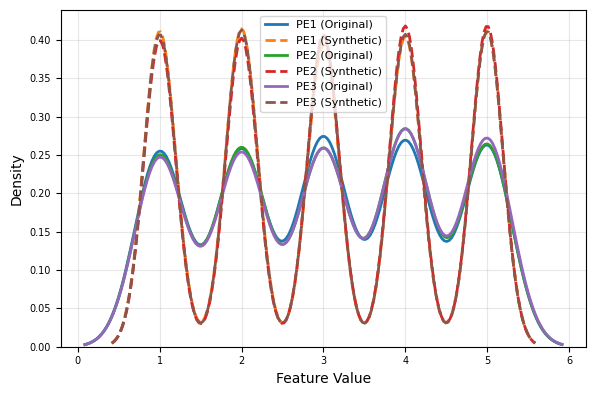

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

features = ['PE1','PE2','PE3']  # adjust if needed

for col in features:
    sns.kdeplot(orig[col], label=f"{col} (Original)", linewidth=2)
    sns.kdeplot(syn[col], linestyle="--", label=f"{col} (Synthetic)", linewidth=2)

plt.xlabel("Feature Value", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Fig1_Distribution.png", dpi=300)
plt.show()

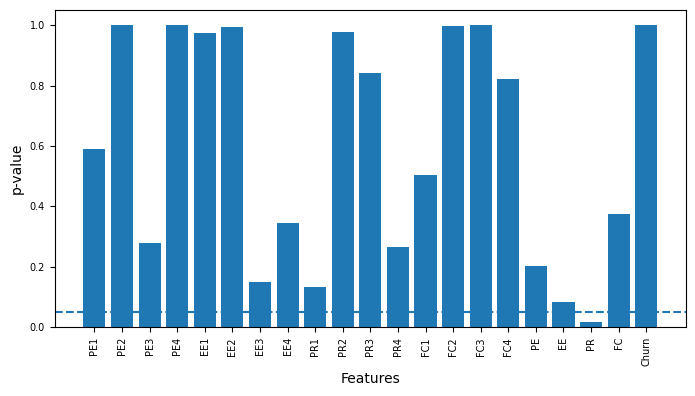

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(ks_df["Feature"], ks_df["p_value"])
plt.axhline(0.05, linestyle='--')

plt.xticks(rotation=90, fontsize=7)
plt.ylabel("p-value", fontsize=10)
plt.xlabel("Features", fontsize=10)

plt.tight_layout()
plt.savefig("Fig2_KS_Test.png", dpi=300)
plt.show()

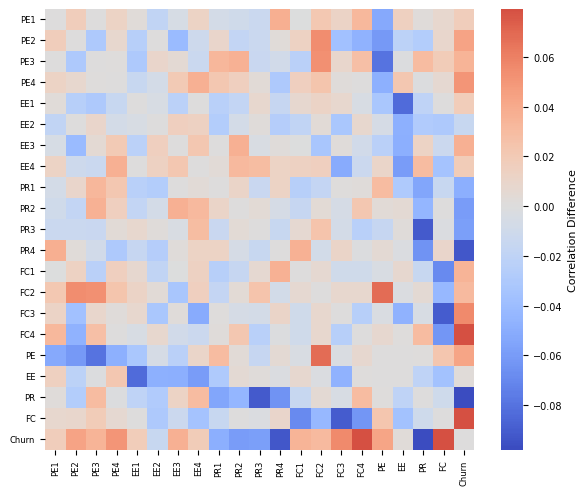

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_diff,
    cmap="coolwarm",
    center=0,
    cbar_kws={'label': 'Correlation Difference'}
)

plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)

plt.tight_layout()
plt.savefig("Fig3_Correlation.png", dpi=300)
plt.show()

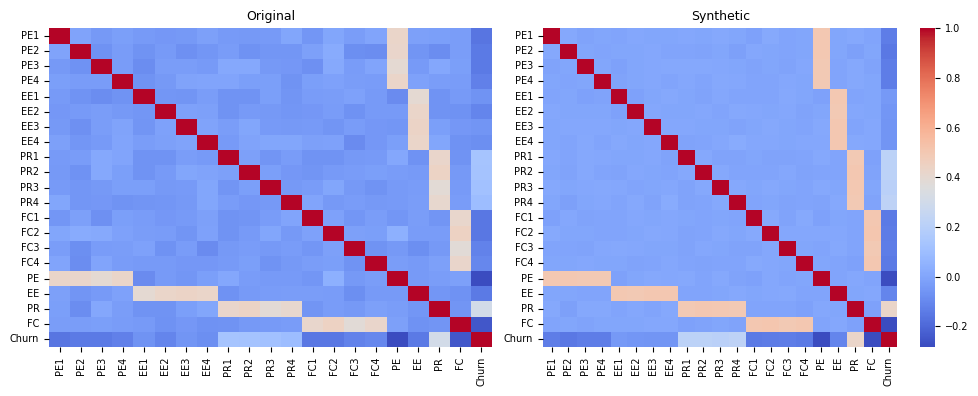

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(corr_orig, ax=axes[0], cmap="coolwarm", cbar=False)
axes[0].set_title("Original")

sns.heatmap(corr_syn, ax=axes[1], cmap="coolwarm")
axes[1].set_title("Synthetic")

plt.tight_layout()
plt.savefig("Fig4_Corr_Comparison.png", dpi=300)
plt.show()

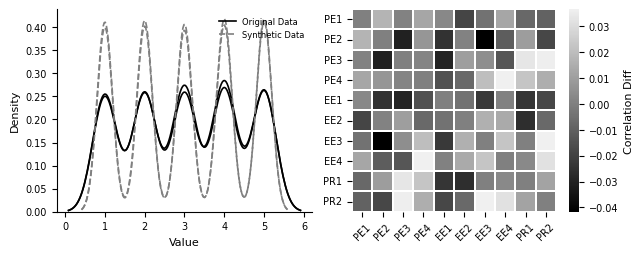

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# LNCS STYLE SETTINGS
# -----------------------
plt.style.use('default')

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 6,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

# Figure size (double column LNCS ~16 cm)
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.6))

# White background (MANDATORY)
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

# -----------------------
# (A) KDE Plot (Cleaner + Less clutter)
# -----------------------
features = ['PE1','PE2']  # reduced for clarity

for col in features:
    sns.kdeplot(
        orig[col],
        ax=axes[0],
        linewidth=1.2,
        color='black'
    )
    sns.kdeplot(
        syn[col],
        ax=axes[0],
        linestyle="--",
        linewidth=1.2,
        color='gray'
    )

axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

# Clean legend (VERY IMPORTANT)
axes[0].legend(
    ["Original Data", "Synthetic Data"],
    loc="upper right",
    frameon=False
)

# Remove top/right borders for clean academic look
sns.despine(ax=axes[0])

# -----------------------
# (B) Correlation Difference (Reduced + readable)
# -----------------------
# Reduce size for readability (IMPORTANT)
corr_diff = (orig[num_cols].corr() - syn[num_cols].corr()).iloc[:10, :10]

sns.heatmap(
    corr_diff,
    ax=axes[1],
    cmap="gray",
    center=0,
    cbar_kws={'label': 'Correlation Diff'},
    linewidths=0.2
)

# Rotate labels for readability
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

sns.despine(ax=axes[1], left=True, bottom=True)

# -----------------------
# FINAL LAYOUT
# -----------------------
plt.tight_layout(pad=1.0)

# Save (VECTOR format for LNCS)
plt.savefig("Fig_validation.pdf", bbox_inches='tight')
plt.savefig("Fig_validation.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

rows = []

for col in num_cols:
    ks_stat, p = stats.ks_2samp(orig[col], syn[col])

    rows.append([
        col,
        orig[col].mean(),
        syn[col].mean(),
        orig[col].std(),
        syn[col].std(),
        p
    ])

val_table = pd.DataFrame(rows, columns=[
    "Feature", "Orig Mean", "Syn Mean",
    "Orig Std", "Syn Std", "KS p-value"
])

val_table["Mean Diff"] = abs(val_table["Orig Mean"] - val_table["Syn Mean"])
val_table["Std Diff"] = abs(val_table["Orig Std"] - val_table["Syn Std"])

val_table = val_table.round(4)

print(val_table)

   Feature  Orig Mean  Syn Mean  Orig Std  Syn Std  KS p-value  Mean Diff  \
0      PE1     3.0199    2.9953    1.4043   1.4210      0.5917     0.0246   
1      PE2     3.0401    3.0260    1.4053   1.4144      0.9989     0.0141   
2      PE3     3.0605    3.0014    1.4094   1.4157      0.2805     0.0592   
3      PE4     3.0067    3.0001    1.4164   1.4134      1.0000     0.0066   
4      EE1     2.9665    2.9891    1.4175   1.4220      0.9739     0.0226   
5      EE2     3.0244    3.0244    1.4297   1.4137      0.9943     0.0000   
6      EE3     2.9054    2.9897    1.4112   1.4160      0.1489     0.0843   
7      EE4     2.9758    3.0069    1.4062   1.4114      0.3442     0.0312   
8      PR1     2.9209    2.9835    1.4212   1.4140      0.1328     0.0626   
9      PR2     2.9659    3.0050    1.4122   1.4135      0.9783     0.0390   
10     PR3     2.9728    3.0000    1.4224   1.4091      0.8404     0.0272   
11     PR4     2.9515    3.0094    1.4195   1.4183      0.2646     0.0578   

In [ ]:
summary_compact = pd.DataFrame({
    "Metric": [
        "Mean Difference (Avg)",
        "Std Difference (Avg)",
        "KS Test (p > 0.05 %)",
        "Max KS p-value",
        "Min KS p-value",
        "Mean Correlation Diff"
    ],
    "Value": [
        val_table["Mean Diff"].mean(),
        val_table["Std Diff"].mean(),
        (val_table["KS p-value"] > 0.05).mean() * 100,
        val_table["KS p-value"].max(),
        val_table["KS p-value"].min(),
        np.abs(corr_diff.values).mean()
    ]
})

print(summary_compact.round(4))

                  Metric    Value
0  Mean Difference (Avg)   0.0307
1   Std Difference (Avg)   0.0073
2   KS Test (p > 0.05 %)  95.2381
3         Max KS p-value   1.0000
4         Min KS p-value   0.0174
5  Mean Correlation Diff   0.0209


In [ ]:
pip install graphviz

In [ ]:
from graphviz import Digraph

dot = Digraph(format='pdf')
dot.attr(rankdir='TB', size='6.5,4.5')

# Global style (LNCS-friendly)
dot.attr('node', shape='box', style='solid', fontsize='10')

# -----------------------
# INPUTS
# -----------------------
dot.node('A', 'Model Outputs\n• Churn Prediction Accuracy\n• Improvement Rate (Δ)')
dot.node('B', 'User Base\n• Total Users (N_users)')
dot.node('C', 'Financial Parameters\n• Customer Lifetime Value (CLV)\n• Discount Rate (r)')

# -----------------------
# CORE MODEL
# -----------------------
dot.node('D',
         'Financial Impact Computation\n'
         'CLV = Σ (R_t - C_t) / (1 + r)^t\n'
         'L_churn = N_churn × CLV\n'
         'G = Δ × N_users × CLV')

# -----------------------
# COST
# -----------------------
dot.node('E', 'Model Cost\n• Training Cost\n• Infrastructure Cost\n• Deployment Cost')

# -----------------------
# OUTPUTS
# -----------------------
dot.node('F', 'Cost-Efficiency\nη = G / C_model')
dot.node('G', 'ROI-Based Decision\n• High Efficiency → Deploy Model\n• Low Efficiency → Reject Model')

# -----------------------
# EDGES (ARROWS)
# -----------------------
dot.edges([
    ('A', 'D'),
    ('B', 'D'),
    ('C', 'D'),
    ('D', 'E'),
    ('D', 'F'),
    ('E', 'G'),
    ('F', 'G')
])

# -----------------------
# RANK ALIGNMENT (CRITICAL)
# -----------------------
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('A')
    s.node('B')
    s.node('C')

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('F')
    s.node('G')

# -----------------------
# SAVE
# -----------------------
dot.render('economic_model_perfect', view=True)

'economic_model_perfect.pdf'

In [ ]:
from graphviz import Digraph

dot = Digraph('framework', format='pdf')

# -----------------------
# GLOBAL STYLE (LNCS)
# -----------------------
dot.attr(rankdir='LR', fontsize='10')

dot.attr('node',
         shape='box',
         style='rounded',
         fontsize='10')

# -----------------------
# DATA LAYER
# -----------------------
dot.node('A',
         'Real Data Collection\n(n = 2,100)\n\nSurvey\n(Online + Offline, Bangladesh)')

dot.node('B',
         'Synthetic Data Generation\n\n• Distribution Preservation\n• Correlation Consistency\n• Gaussian Noise Injection')

dot.node('C',
         'Hybrid Dataset\n(>20,000 samples)')

# -----------------------
# FEATURE ENGINEERING
# -----------------------
dot.node('D',
         'Behavioral Feature Construction\n\n• UTAUT Constructs\n(PE, EE, PR, FC)\n• Aggregation (Mean Scores)\n• Interaction Features\n(PE×FC, EE×PR, PR×FC)')

# -----------------------
# PREDICTIVE MODELS (STACKED)
# -----------------------
dot.node('E1', 'Logistic Regression\n(Most Cost-Efficient Model)')
dot.node('E2', 'Random Forest')
dot.node('E3', 'XGBoost')
dot.node('E4', 'Deep Neural Network')

# Align models vertically
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('E1')
    s.node('E2')
    s.node('E3')
    s.node('E4')

# -----------------------
# OUTPUT
# -----------------------
dot.node('F', 'Churn Prediction\n(Binary Output)')

# -----------------------
# ECONOMIC EVALUATION
# -----------------------
dot.node('G',
         'Economic Impact Analysis\n\n• Customer Lifetime Value (CLV)\n• Retention Gain (Δ)\n• Cost-Efficiency\n(η = G / C_model)')

dot.node('H', 'Business Decision Support')

# -----------------------
# EDGES (FLOW)
# -----------------------
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')

dot.edge('D', 'E1')
dot.edge('D', 'E2')
dot.edge('D', 'E3')
dot.edge('D', 'E4')

dot.edge('E1', 'F')
dot.edge('E2', 'F')
dot.edge('E3', 'F')
dot.edge('E4', 'F')

dot.edge('F', 'G')
dot.edge('G', 'H')

# -----------------------
# LAYER LABELS (TOP HEADERS)
# -----------------------
dot.attr('node', shape='plaintext', fontsize='11')

dot.node('L1', 'Data Layer')
dot.node('L2', 'Feature Engineering')
dot.node('L3', 'Predictive Modeling')
dot.node('L4', 'Economic Evaluation')

# Align headers
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('L1')
    s.node('L2')
    s.node('L3')
    s.node('L4')

# Invisible edges to align headers with columns
dot.edge('L1', 'A', style='invis')
dot.edge('L2', 'D', style='invis')
dot.edge('L3', 'E1', style='invis')
dot.edge('L4', 'G', style='invis')

# -----------------------
# OUTPUT
# -----------------------
dot.render('churn_framework_lncs', view=True)

'churn_framework_lncs.pdf'

In [ ]:
from graphviz import Digraph

dot = Digraph('framework_vertical', format='pdf')

# -----------------------
# GLOBAL STYLE (LNCS SAFE)
# -----------------------
dot.attr(rankdir='TB')  # TOP → BOTTOM (VERTICAL)
dot.attr(nodesep='0.6', ranksep='0.8')

dot.attr('node',
         shape='box',
         style='rounded',
         fontsize='10')

# -----------------------
# ROW 1 (TOP FLOW)
# -----------------------
dot.node('A', 'Real Data Collection\n(n = 2,100)\nSurvey (Bangladesh)')
dot.node('B', 'Synthetic Data Generation\n• Distribution\n• Correlation\n• Noise')
dot.node('C', 'Hybrid Dataset\n(>20,000 samples)')
dot.node('D', 'Behavioral Features\nUTAUT (PE, EE, PR, FC)\n+ Interactions')

dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')

# -----------------------
# ROW 2 (MODELS - CENTERED STACK)
# -----------------------
dot.node('E1', 'Logistic Regression\n(Most Cost-Efficient)')
dot.node('E2', 'Random Forest')
dot.node('E3', 'XGBoost')
dot.node('E4', 'Deep Neural Network')

# Align vertically
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('E1')
    s.node('E2')
    s.node('E3')
    s.node('E4')

# Connect feature → models
dot.edge('D', 'E1')
dot.edge('D', 'E2')
dot.edge('D', 'E3')
dot.edge('D', 'E4')

# -----------------------
# ROW 3 (OUTPUT FLOW)
# -----------------------
dot.node('F', 'Churn Prediction\n(Binary Output)')

dot.edge('E1', 'F')
dot.edge('E2', 'F')
dot.edge('E3', 'F')
dot.edge('E4', 'F')

# -----------------------
# ROW 4 (ECONOMIC)
# -----------------------
dot.node('G',
         'Economic Impact Analysis\n\n'
         '• CLV\n'
         '• Retention Gain (Δ)\n'
         '• Cost-Efficiency\n'
         '(η = G / C_model)')

dot.node('H', 'Business Decision Support')

dot.edge('F', 'G')
dot.edge('G', 'H')

# -----------------------
# SIDE LABELS (LNCS STYLE)
# -----------------------
dot.attr('node', shape='plaintext', fontsize='11')

dot.node('L1', 'Data Layer')
dot.node('L2', 'Feature Engineering')
dot.node('L3', 'Predictive Modeling')
dot.node('L4', 'Economic Evaluation')

# Align labels vertically
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('L1')
    s.node('L2')
    s.node('L3')
    s.node('L4')

# Invisible alignment edges
dot.edge('L1', 'A', style='invis')
dot.edge('L2', 'D', style='invis')
dot.edge('L3', 'E1', style='invis')
dot.edge('L4', 'G', style='invis')

# -----------------------
# EXPORT (CAMERA READY)
# -----------------------
dot.render('churn_framework_vertical_lncs', view=True)

'churn_framework_vertical_lncs.pdf'

In [ ]:
from graphviz import Digraph

dot = Digraph('framework_lncs_exact', format='pdf')

# -----------------------
# GLOBAL STYLE (LNCS SAFE)
# -----------------------
dot.attr(rankdir='LR')  # KEEP horizontal layout
dot.attr(nodesep='0.4', ranksep='0.6')

dot.attr('node',
         shape='box',
         style='rounded',
         fontsize='9',
         fontname='Times-Roman')

# -----------------------
# DATA LAYER
# -----------------------
dot.node('A',
         'Real Data Collection\n(n = 2,100)\n\nSurvey\n(Online + Offline, Bangladesh)')

dot.node('B',
         'Synthetic Data Generation\n\n'
         '• Distribution Preservation\n'
         '• Correlation Consistency\n'
         '• Gaussian Noise Injection')

dot.node('C',
         'Hybrid Dataset\n(>20,000 samples)')

# -----------------------
# FEATURE ENGINEERING
# -----------------------
dot.node('D',
         'Behavioral Feature Construction\n\n'
         '• UTAUT Constructs (PE, EE, PR, FC)\n'
         '• Aggregation (Mean Scores)\n'
         '• Interaction Features\n'
         '(PE×FC, EE×PR, PR×FC)')

# -----------------------
# MODELS (VERTICAL STACK)
# -----------------------
dot.node('E1', 'Logistic Regression\n(Most Cost-Efficient Model)')
dot.node('E2', 'Random Forest')
dot.node('E3', 'XGBoost')
dot.node('E4', 'Deep Neural Network')

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('E1')
    s.node('E2')
    s.node('E3')
    s.node('E4')

# -----------------------
# OUTPUT
# -----------------------
dot.node('F', 'Churn Prediction\n(Binary Output)')

# -----------------------
# ECONOMIC
# -----------------------
dot.node('G',
         'Economic Impact Analysis\n\n'
         '• Customer Lifetime Value (CLV)\n'
         '• Retention Gain (Δ)\n'
         '• Cost-Efficiency\n'
         '(η = G / C_model)')

dot.node('H', 'Business Decision Support')

# -----------------------
# FLOW
# -----------------------
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')

dot.edge('D', 'E1')
dot.edge('D', 'E2')
dot.edge('D', 'E3')
dot.edge('D', 'E4')

dot.edge('E1', 'F')
dot.edge('E2', 'F')
dot.edge('E3', 'F')
dot.edge('E4', 'F')

dot.edge('F', 'G')
dot.edge('G', 'H')

# -----------------------
# COLUMN HEADERS (IMPORTANT)
# -----------------------
dot.attr('node', shape='plaintext', fontsize='10', fontname='Times-Bold')

dot.node('L1', 'Data Layer')
dot.node('L2', 'Feature Engineering')
dot.node('L3', 'Predictive Modeling')
dot.node('L4', 'Economic Evaluation')

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('L1')
    s.node('L2')
    s.node('L3')
    s.node('L4')

# Invisible alignment edges
dot.edge('L1', 'A', style='invis')
dot.edge('L2', 'D', style='invis')
dot.edge('L3', 'E1', style='invis')
dot.edge('L4', 'G', style='invis')

# -----------------------
# EXPORT (LNCS READY)
# -----------------------
dot.render('churn_framework_lncs_final', view=True)

'churn_framework_lncs_final.pdf'

In [ ]:
from graphviz import Digraph

dot = Digraph('framework_compact', format='pdf')

# -----------------------
# GLOBAL SETTINGS (KEY FIX)
# -----------------------
dot.attr(rankdir='LR')

# 🔥 REDUCE SPACING (IMPORTANT)
dot.attr(nodesep='0.2', ranksep='0.35')

dot.attr('node',
         shape='box',
         style='rounded',
         fontsize='9',
         fontname='Times-Roman')

# -----------------------
# DATA LAYER
# -----------------------
dot.node('A',
         'Real Data Collection\n(n = 2,100)\nSurvey (Bangladesh)')

dot.node('B',
         'Synthetic Data Generation\n'
         '• Distribution\n'
         '• Correlation\n'
         '• Noise')

dot.node('C',
         'Hybrid Dataset\n(>20,000 samples)')

# -----------------------
# FEATURE ENGINEERING
# -----------------------
dot.node('D',
         'Behavioral Features\n'
         'UTAUT (PE, EE, PR, FC)\n'
         '+ Interactions')

# -----------------------
# MODELS (TIGHT STACK)
# -----------------------
dot.node('E1', 'Logistic Regression\n(Most Cost-Efficient)')
dot.node('E2', 'Random Forest')
dot.node('E3', 'XGBoost')
dot.node('E4', 'Deep Neural Network')

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('E1')
    s.node('E2')
    s.node('E3')
    s.node('E4')

# -----------------------
# OUTPUT
# -----------------------
dot.node('F', 'Churn Prediction\n(Binary Output)')

# -----------------------
# ECONOMIC
# -----------------------
dot.node('G',
         'Economic Impact Analysis\n'
         '• CLV\n'
         '• Gain (Δ)\n'
         '• Efficiency\n(η = G / C_model)')

dot.node('H', 'Decision Support')

# -----------------------
# EDGES (SHORTER ARROWS)
# -----------------------

# Use constraint + weight to tighten edges
dot.edge('A', 'B', weight='3')
dot.edge('B', 'C', weight='3')
dot.edge('C', 'D', weight='3')

dot.edge('D', 'E1', weight='2')
dot.edge('D', 'E2', weight='2')
dot.edge('D', 'E3', weight='2')
dot.edge('D', 'E4', weight='2')

dot.edge('E1', 'F', weight='2')
dot.edge('E2', 'F', weight='2')
dot.edge('E3', 'F', weight='2')
dot.edge('E4', 'F', weight='2')

dot.edge('F', 'G', weight='3')
dot.edge('G', 'H', weight='3')

# -----------------------
# HEADERS (COMPACT)
# -----------------------
dot.attr('node', shape='plaintext', fontsize='10', fontname='Times-Bold')

dot.node('L1', 'Data')
dot.node('L2', 'Features')
dot.node('L3', 'Models')
dot.node('L4', 'Economic')

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('L1')
    s.node('L2')
    s.node('L3')
    s.node('L4')

dot.edge('L1', 'A', style='invis')
dot.edge('L2', 'D', style='invis')
dot.edge('L3', 'E1', style='invis')
dot.edge('L4', 'G', style='invis')

# -----------------------
# EXPORT
# -----------------------
dot.render('churn_framework_compact_lncs', view=True)

'churn_framework_compact_lncs.pdf'

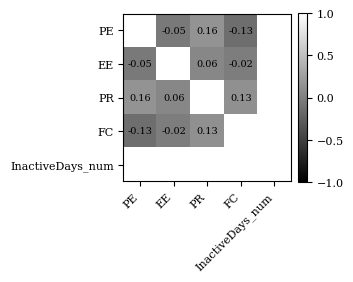

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# STEP 1 — CLEAN & CONVERT DATA
# ===============================
# Convert to numeric
df["InactiveDays_num"] = pd.to_numeric(df["InactiveDays"], errors="coerce")

# Manual mapping if needed
if df["InactiveDays_num"].isnull().sum() > 0:
    df["InactiveDays_num"] = df["InactiveDays"].replace({
        "0 days": 0,
        "1-30 days": 15,
        "1–30 days": 15,
        "31-60 days": 45,
        "60+ days": 75,
        "More then 30days": 45
    })

# Final numeric enforcement
df["InactiveDays_num"] = pd.to_numeric(df["InactiveDays_num"], errors="coerce")

# ===============================
# STEP 2 — SELECT VALID DATA ONLY
# ===============================
cols = ["PE", "EE", "PR", "FC", "InactiveDays_num"]

# Drop rows where ANY required column is missing
df_corr = df[cols].dropna()

# Safety check (prevents empty matrix issue)
if df_corr.shape[0] == 0:
    raise ValueError("No valid data available after cleaning. Check InactiveDays mapping.")

# ===============================
# STEP 3 — COMPUTE CORRELATION
# ===============================
corr_matrix = df_corr.corr()

# Ensure full matrix exists
assert corr_matrix.shape[0] == len(cols), "Correlation matrix incomplete"

# ===============================
# STEP 4 — LNCS STYLE SETTINGS
# ===============================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# ===============================
# STEP 5 — PLOT (GRAYSCALE SAFE)
# ===============================
fig, ax = plt.subplots(figsize=(3.5, 3))

cax = ax.imshow(corr_matrix, cmap="gray", vmin=-1, vmax=1)

# Axis ticks
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))

ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# ===============================
# STEP 6 — ANNOTATIONS
# ===============================
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black" if abs(val) < 0.6 else "white"
        )

# ===============================
# STEP 7 — COLORBAR
# ===============================
cbar = fig.colorbar(cax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)

# ===============================
# STEP 8 — FINAL LAYOUT
# ===============================
plt.tight_layout()

# ===============================
# STEP 9 — SAVE (LNCS REQUIRED)
# ===============================
plt.savefig("correlation_heatmap_lncs.pdf", format="pdf", bbox_inches="tight")
plt.savefig("correlation_heatmap_lncs.eps", format="eps", bbox_inches="tight")

plt.show()